In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("churn-bigml-20.csv")

df.head()

Saving churn-bigml-20.csv to churn-bigml-20 (1).csv


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [ ]:
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['Churn'].value_counts())

Dataset Shape: (667, 20)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  To

In [ ]:
df_processed = df.copy()

label_encoder = LabelEncoder()

df_processed['State'] = label_encoder.fit_transform(df_processed['State'])

df_processed['International plan'] = label_encoder.fit_transform(
    df_processed['International plan']
)

df_processed['Voice mail plan'] = label_encoder.fit_transform(
    df_processed['Voice mail plan']
)

df_processed['Churn'] = label_encoder.fit_transform(
    df_processed['Churn']
)

df_processed.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,18,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
1,15,65,415,0,0,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
2,34,161,415,0,0,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
3,40,111,415,0,0,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
4,11,49,510,0,0,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0


In [ ]:
X = df_processed.drop('Churn', axis=1)

y = df_processed['Churn']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (667, 19)
Target Shape: (667,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 533
Testing Samples: 134


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8582089552238806
Precision: 0.5
Recall   : 0.15789473684210525
F1 Score : 0.24


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[112   3]
 [ 16   3]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       115
           1       0.50      0.16      0.24        19

    accuracy                           0.86       134
   macro avg       0.69      0.57      0.58       134
weighted avg       0.82      0.86      0.83       134



In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8164759725400458


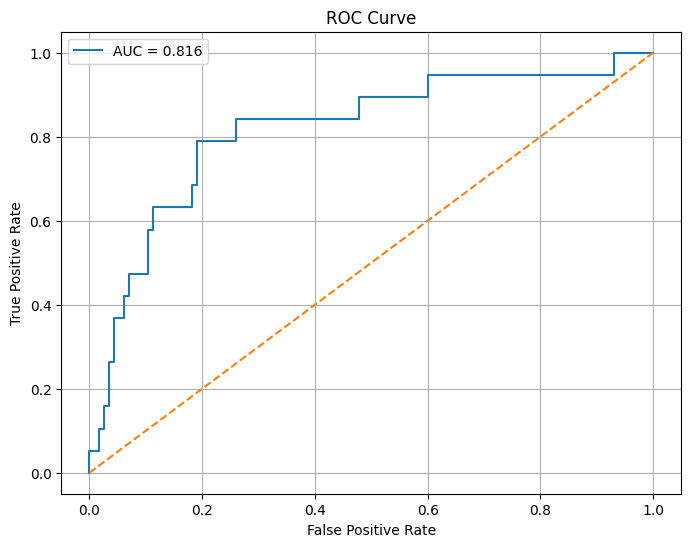

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                   Feature  Coefficient
18  Customer service calls     0.799155
3       International plan     0.544397
6        Total day minutes     0.380661
8         Total day charge     0.380623
11        Total eve charge     0.325371
9        Total eve minutes     0.325236
10         Total eve calls     0.172828
14      Total night charge     0.163568
12     Total night minutes     0.163312
17       Total intl charge     0.115057
15      Total intl minutes     0.113755
7          Total day calls     0.107215
0                    State     0.024910
1           Account length     0.006729
16        Total intl calls    -0.006890
2                Area code    -0.061920
13       Total night calls    -0.086137
4          Voice mail plan    -0.267957
5    Number vmail messages    -0.278512


In [ ]:
coefficients['Odds Ratio'] = np.exp(
    coefficients['Coefficient']
)

print(coefficients)

                   Feature  Coefficient  Odds Ratio
18  Customer service calls     0.799155    2.223660
3       International plan     0.544397    1.723568
6        Total day minutes     0.380661    1.463251
8         Total day charge     0.380623    1.463196
11        Total eve charge     0.325371    1.384544
9        Total eve minutes     0.325236    1.384358
10         Total eve calls     0.172828    1.188662
14      Total night charge     0.163568    1.177706
12     Total night minutes     0.163312    1.177404
17       Total intl charge     0.115057    1.121938
15      Total intl minutes     0.113755    1.120477
7          Total day calls     0.107215    1.113174
0                    State     0.024910    1.025223
1           Account length     0.006729    1.006751
16        Total intl calls    -0.006890    0.993133
2                Area code    -0.061920    0.939958
13       Total night calls    -0.086137    0.917468
4          Voice mail plan    -0.267957    0.764941
5    Number 